In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(len(os.listdir('/content/drive/MyDrive/flickr8k/Images')))
print(os.path.exists('/content/drive/MyDrive/flickr8k/captions.txt'))

Mounted at /content/drive
8096
True


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import shutil, os
shutil.copytree('/content/drive/MyDrive/flickr8k/Images', '/content/Images')
print("Done:", len(os.listdir('/content/Images')), "images copied")

Done: 8096 images copied


In [7]:
import os
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Embedding, Dropout, Add
)

In [4]:
import pickle

# Load saved features (no need to re-run VGG16!)
with open('/content/drive/MyDrive/flickr8k/features.pkl', 'rb') as f:
    features = pickle.load(f)
print("Features loaded:", len(features))

# Load saved tokenizer
with open('/content/drive/MyDrive/flickr8k/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
print("Tokenizer loaded ✅")

Features loaded: 8096
Tokenizer loaded ✅


In [5]:
# LOAD AND CLEAN CAPTIONS
def load_captions(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    captions = {}
    for line in lines:
        parts = line.strip().split('\t')  # tab separated, NOT comma
        if len(parts) != 2:
            continue

        # removes the #0 #1 #2 part from image name
        image_name = parts[0].split('#')[0].strip()
        caption = parts[1].strip().lower()
        caption = re.sub(r"[^a-z\s]", "", caption)
        caption = "startseq " + caption + " endseq"

        if image_name not in captions:
            captions[image_name] = []
        captions[image_name].append(caption)

    return captions

In [8]:
# ── change these paths to match your Colab paths ──
# COLAB PATHS
IMAGES_DIR    = '/content/drive/MyDrive/flickr8k/Images'
CAPTIONS_FILE = '/content/drive/MyDrive/flickr8k/captions.txt'

captions = load_captions(CAPTIONS_FILE)
print(f"Total images: {len(captions)}")         # should be ~8000
print(f"Sample: {captions[list(captions.keys())[0]]}")


Total images: 8092
Sample: ['startseq a child in a pink dress is climbing up a set of stairs in an entry way  endseq', 'startseq a girl going into a wooden building  endseq', 'startseq a little girl climbing into a wooden playhouse  endseq', 'startseq a little girl climbing the stairs to her playhouse  endseq', 'startseq a little girl in a pink dress going into a wooden cabin  endseq']


In [9]:
# EXTRACT IMAGE FEATURES USING VGG16
def extract_features(images_dir):
    # load VGG16, remove last layer, keep 4096-dim output
    base_model = VGG16()
    model = Model(inputs=base_model.inputs,
                  outputs=base_model.layers[-2].output)
    print("VGG16 loaded ✅")

    features = {}
    for img_name in tqdm(os.listdir(images_dir)):
        img_path = os.path.join(images_dir, img_name)
        img = Image.open(img_path).resize((224, 224))
        img = np.array(img)

        if img.shape != (224, 224, 3):   # skip grayscale/corrupt images
            continue

        img = img / 255.0                # normalize
        img = np.expand_dims(img, axis=0)
        feature = model.predict(img, verbose=0)
        features[img_name] = feature

    return features


# This takes ~15 mins on GPU — run ONCE then save
features = extract_features(IMAGES_DIR)
print(f"Features extracted: {len(features)}")

# Save so you never run VGG16 again
with open('/content/drive/MyDrive/flickr8k/features.pkl', 'wb') as f:
    pickle.dump(features, f)
print("Features saved to Drive ✅")


VGG16 loaded ✅


100%|██████████| 8096/8096 [15:45<00:00,  8.57it/s]


Features extracted: 8096
Features saved to Drive ✅


In [13]:
#BUILD VOCABULARY
# Collect all captions into one flat list
all_captions = []
for caps in captions.values():
    all_captions.extend(caps)

# Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

print(f"Vocabulary size : {vocab_size}")    # ~8000-9000
print(f"Max caption length: {max_length}")  # ~35-40

# Save tokenizer
with open('/content/drive/MyDrive/flickr8k/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved ✅")


Vocabulary size : 8781
Max caption length: 37
Tokenizer saved ✅


In [14]:
#DATA GENERATOR
def data_generator(captions, features, tokenizer,
                   max_length, vocab_size, batch_size=32):
    image_names = list(captions.keys())
    while True:
        for i in range(0, len(image_names), batch_size):
            batch = image_names[i: i + batch_size]

            X_img, X_seq, y = [], [], []

            for img_name in batch:
                if img_name not in features:
                    continue
                feat = features[img_name][0]   # shape (4096,)

                for cap in captions[img_name]:
                    seq = tokenizer.texts_to_sequences([cap])[0]
                    for t in range(1, len(seq)):
                        in_seq  = pad_sequences([seq[:t]],
                                                maxlen=max_length)[0]
                        out_word = to_categorical([seq[t]],
                                                  num_classes=vocab_size)[0]
                        X_img.append(feat)
                        X_seq.append(in_seq)
                        y.append(out_word)

            yield ([np.array(X_img), np.array(X_seq)],
                   np.array(y))


In [16]:
import tensorflow as tf

def build_model(vocab_size, max_length):
    img_input  = Input(shape=(4096,))
    img_dense  = Dense(256, activation='relu')(img_input)
    img_drop   = Dropout(0.4)(img_dense)

    text_input = Input(shape=(max_length,))
    text_embed = Embedding(vocab_size, 256, mask_zero=True)(text_input)
    text_drop  = Dropout(0.4)(text_embed)
    text_lstm  = LSTM(256, use_cudnn=False)(text_drop)

    merged = Add()([img_drop, text_lstm])
    dense1 = Dense(256, activation='relu')(merged)
    output = Dense(vocab_size, activation='softmax')(dense1)

    model = Model(inputs=[img_input, text_input], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = build_model(vocab_size, max_length)
model.summary()

# ── Generator function ──
def data_generator():
    for img_name, caps in captions.items():
        if img_name not in features:
            continue
        feat = features[img_name][0]
        for cap in caps:
            seq = tokenizer.texts_to_sequences([cap])[0]
            for t in range(1, len(seq)):
                in_seq   = pad_sequences([seq[:t]], maxlen=max_length)[0]
                out_word = to_categorical([seq[t]], num_classes=vocab_size)[0]
                yield (feat, in_seq), out_word

# ── Wrap in tf.data.Dataset ──
dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=(
        (
            tf.TensorSpec(shape=(4096,),      dtype=tf.float32),
            tf.TensorSpec(shape=(max_length,), dtype=tf.int32)
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
    )
)

dataset = dataset.batch(64).prefetch(tf.data.AUTOTUNE)

# ── Train ──
EPOCHS = 20

for epoch in range(EPOCHS):
    model.fit(dataset, epochs=1, verbose=1)
    model.save(f'/content/drive/MyDrive/flickr8k/model_epoch_{epoch+1}.h5')
    print(f"Epoch {epoch+1} saved ✅")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 37, 256)   │  2,247,936 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │  1,048,832 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 37, 256)   │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 37)        │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 256)       │    525,312 │ dropout_5[0][0],  │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ dropout_4[0][0],  │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8781)      │  2,256,717 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,144,589 (23.44 MB)

 Trainable params: 6,144,589 (23.44 MB)

 Non-trainable params: 0 (0.00 B)

...

Epoch 16 saved ✅
7450/7450 ━━━━━━━━━━━━━━━━━━━━ 277s 37ms/step - loss: 2.5134


Epoch 17 saved ✅
7450/7450 ━━━━━━━━━━━━━━━━━━━━ 277s 37ms/step - loss: 2.5048


Epoch 18 saved ✅
7450/7450 ━━━━━━━━━━━━━━━━━━━━ 277s 37ms/step - loss: 2.4981


Epoch 19 saved ✅
7450/7450 ━━━━━━━━━━━━━━━━━━━━ 278s 37ms/step - loss: 2.4949


Epoch 20 saved ✅


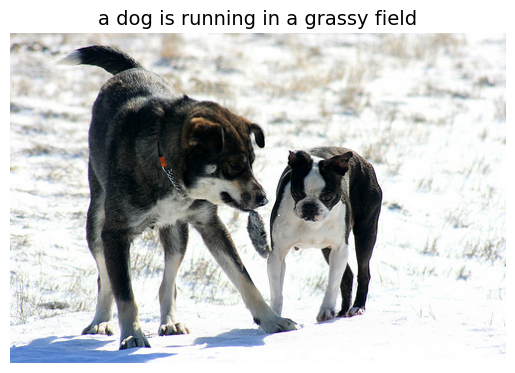

Image   : 3354474353_daf9e168cf.jpg
Caption : a dog is running in a grassy field


In [19]:
# ── CAPTION GENERATOR ──
def generate_caption(model, tokenizer, photo_feature, max_length, temperature=0.5):
    in_text = 'startseq'

    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length)

        yhat = model.predict([photo_feature, seq], verbose=0)[0]

        # Temperature sampling instead of plain argmax
        yhat = np.log(yhat + 1e-10) / temperature
        yhat = np.exp(yhat) / np.sum(np.exp(yhat))
        yhat_index = np.random.choice(len(yhat), p=yhat)

        word = tokenizer.index_word.get(yhat_index, None)

        if word is None or word == 'endseq':
            break

        in_text += ' ' + word

    final_caption = in_text.replace('startseq', '').strip()
    return final_caption

# ── TEST ON A RANDOM IMAGE ──
import random
import matplotlib.pyplot as plt
from PIL import Image

# Pick a random image
test_img_name = random.choice(list(features.keys()))
test_feature  = features[test_img_name]

# Generate caption
caption = generate_caption(model, tokenizer, test_feature, max_length)

# Show image + caption
img = Image.open(f'/content/Images/{test_img_name}')
plt.imshow(img)
plt.axis('off')
plt.title(caption, fontsize=14, wrap=True)
plt.show()

print(f"Image   : {test_img_name}")
print(f"Caption : {caption}")

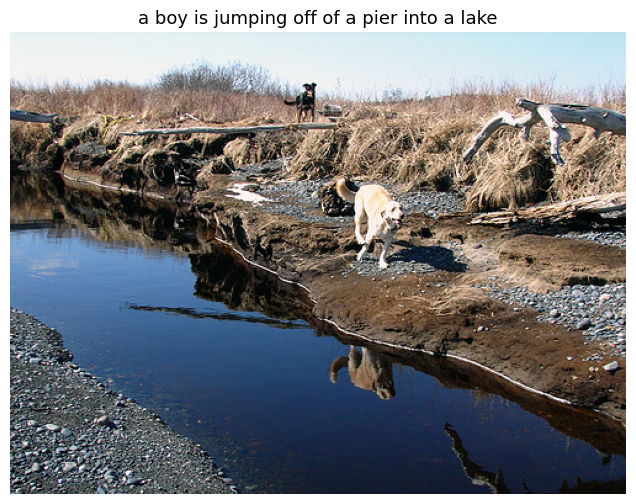

Caption: a boy is jumping off of a pier into a lake



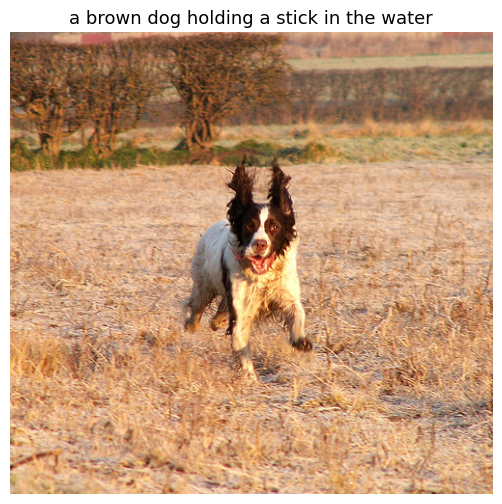

Caption: a brown dog holding a stick in the water



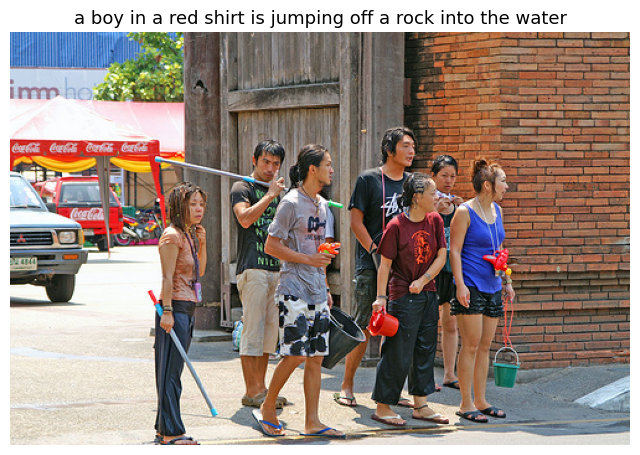

Caption: a boy in a red shirt is jumping off a rock into the water



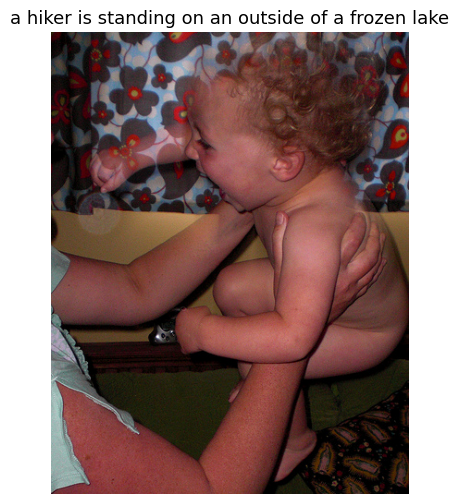

Caption: a hiker is standing on an outside of a frozen lake



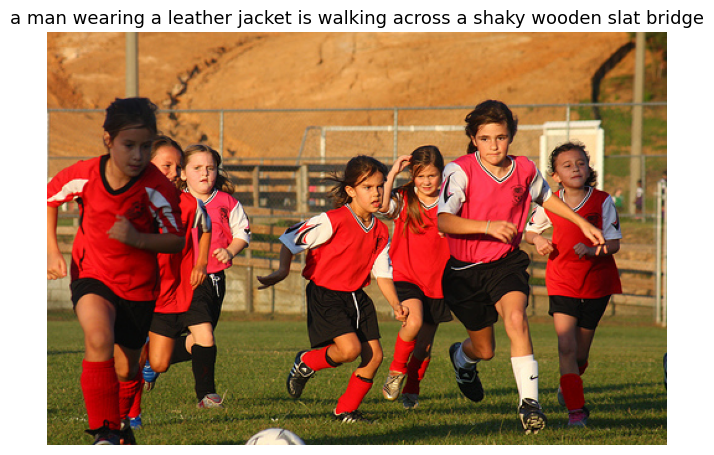

Caption: a man wearing a leather jacket is walking across a shaky wooden slat bridge



In [20]:
import random

for i in range(5):
    test_img_name = random.choice(list(features.keys()))
    test_feature  = features[test_img_name]

    caption = generate_caption(model, tokenizer,
                               test_feature, max_length)

    img = Image.open(f'/content/Images/{test_img_name}')
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(caption, fontsize=13, wrap=True)
    plt.show()
    print(f"Caption: {caption}\n")

In [21]:
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [22]:
def evaluate_bleu(model, captions, features, tokenizer, max_length):
    actual    = []
    predicted = []

    # Test on 500 images (faster than all 8000)
    test_images = list(captions.keys())[:500]

    print("Generating captions for 500 images...")
    for img_name in tqdm(test_images):
        if img_name not in features:
            continue

        # Real captions (remove startseq/endseq)
        real_caps = []
        for cap in captions[img_name]:
            clean = cap.replace('startseq', '').replace('endseq', '').strip()
            real_caps.append(clean.split())
        actual.append(real_caps)

        # Generated caption
        generated = generate_caption(model, tokenizer,
                                     features[img_name], max_length)
        predicted.append(generated.split())

    # Calculate BLEU scores
    bleu1 = corpus_bleu(actual, predicted, weights=(1,0,0,0))
    bleu2 = corpus_bleu(actual, predicted, weights=(0.5,0.5,0,0))
    bleu3 = corpus_bleu(actual, predicted, weights=(0.33,0.33,0.33,0))
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25,0.25,0.25,0.25))

    print(f"\n----- BLEU Scores -----")
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-3: {bleu3:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")

    return bleu1, bleu2, bleu3, bleu4

bleu1, bleu2, bleu3, bleu4 = evaluate_bleu(
    model, captions, features, tokenizer, max_length
)

Generating captions for 500 images...


100%|██████████| 500/500 [10:01<00:00,  1.20s/it]



----- BLEU Scores -----
BLEU-1: 0.3869
BLEU-2: 0.1912
BLEU-3: 0.0924
BLEU-4: 0.0479


In [23]:
# Re-evaluate with temperature sampling
def generate_caption(model, tokenizer, photo_feature,
                     max_length, temperature=0.5):
    in_text = 'startseq'
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length)
        yhat = model.predict([photo_feature, seq], verbose=0)[0]
        yhat = np.log(yhat + 1e-10) / temperature
        yhat = np.exp(yhat) / np.sum(np.exp(yhat))
        yhat_index = np.random.choice(len(yhat), p=yhat)
        word = tokenizer.index_word.get(yhat_index, None)
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()

# Run BLEU again
bleu1, bleu2, bleu3, bleu4 = evaluate_bleu(
    model, captions, features, tokenizer, max_length
)

Generating captions for 500 images...


100%|██████████| 500/500 [09:58<00:00,  1.20s/it]



----- BLEU Scores -----
BLEU-1: 0.3911
BLEU-2: 0.1917
BLEU-3: 0.0909
BLEU-4: 0.0450
